In [ ]:
%load_ext autoreload

import sys

import torch as th
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torch.utils.data import TensorDataset

from neuralop.models import FNO, GINO
from neuralop import H1Loss

from tqdm.auto import tqdm
# from neuralop import Trainer
# from neuralop.data.datasets import load_darcy_flow_small

device = 'cuda' if th.cuda.is_available() else 'cpu'

/home/alex/miniforge3/envs/no/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def rasterize(mesh_coordinates, permeability, solution):
    x = mesh_coordinates[0, :, 0]
    y = mesh_coordinates[0, :, 1]

    x_unique = np.sort(np.unique(x))
    y_unique = np.sort(np.unique(y))

    perm_2d = np.zeros((65, 65))
    sol2d = np.zeros((65, 65))

    for i in range(len(x)):
        col_idx = np.searchsorted(x_unique, x[i])
        row_idx = np.searchsorted(y_unique, y[i])
        perm_2d[row_idx, col_idx] = permeability[i]
        sol2d[row_idx, col_idx] = solution[i]

    return perm_2d, sol2d


In [19]:
lfno = FNO(n_modes=(128, 128),
             in_channels=1, 
             out_channels=1,
             hidden_channels=32, 
             projection_channel_ratio=2)

In [15]:
def normalize(tensor):
    """
    Normalize a tensor to have mean 0 and standard deviation 1
    Returns the normalized tensor and the mean and std used for normalization
    """
    mean = tensor.mean()
    std = tensor.std()
    normalized = (tensor - mean) / std
    return normalized, mean, std

def denormalize(normalized_tensor, mean, std):
    """
    Denormalize a tensor using the provided mean and standard deviation
    """
    original = normalized_tensor * std + mean
    return original

In [16]:
mesh_coordinates = np.load("darcy_flow_training_data/mesh_coordinates.npy")[None]
mesh_connectivity = np.load("darcy_flow_training_data/cells.npy")
permeability = np.load("darcy_flow_training_data/permeability.npy")
solution = np.load("darcy_flow_training_data/solution.npy")

permeability_data, solution_data = [], []

for p, s in tqdm(zip(permeability, solution)):
    p2d, s2d = rasterize(mesh_coordinates, p, s)
    permeability_data.append(p2d)
    solution_data.append(s2d)


permeability = th.tensor(np.array(permeability_data), dtype=th.float32)[:, None]
norm_permeability, mean_perm, std_perm = normalize(permeability)

solution = th.tensor(np.array(solution_data), dtype=th.float32)[:, None]
norm_solution, mean_sol, std_sol = normalize(solution)


dataset = TensorDataset(norm_permeability, norm_solution)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

1000it [00:19, 50.21it/s]


In [20]:
optimizer = th.optim.AdamW(
    lfno.parameters(), 
    lr=8e-3, 
    weight_decay=1e-4
)
scheduler = th.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
h1loss = H1Loss(d=2)

In [21]:
%autoreload
lfno = lfno.to(device)


for epoch in tqdm(range(100), file=sys.stdout):
    lfno.train()
    for batch in train_loader:
        optimizer.zero_grad()
        p, s = batch
        p, s = p.to(device), s.to(device)
        s_pred = lfno(p)
        loss = h1loss(s_pred, s)
        loss.backward()
        optimizer.step()
    scheduler.step()

    lfno.eval()
    test_loss = 0
    for batch in test_loader:
        p, s = batch
        p, s = p.to(device), s.to(device)
        s_pred = lfno(p)
        test_loss += h1loss(s_pred, s).item()
    if epoch % 10 == 0:
        tqdm.write(f"Epoch {epoch} Test Loss: {test_loss / len(test_loader)}")

    

Epoch 0 Test Loss: 5.649091482162476   
Epoch 10 Test Loss: 2.3880554011889865          
Epoch 20 Test Loss: 2.2581441572734287          
Epoch 30 Test Loss: 2.2493757009506226          
Epoch 40 Test Loss: 2.4115911551884244          
Epoch 50 Test Loss: 2.7422473771231517          
Epoch 60 Test Loss: 2.652659373623984           
Epoch 70 Test Loss: 2.3893980298723494          
Epoch 80 Test Loss: 2.2384844848087857          
Epoch 90 Test Loss: 2.237616981778826           
100%|██████████| 100/100 [03:45<00:00,  2.26s/it]


Text(0.5, 1.0, 'Difference')

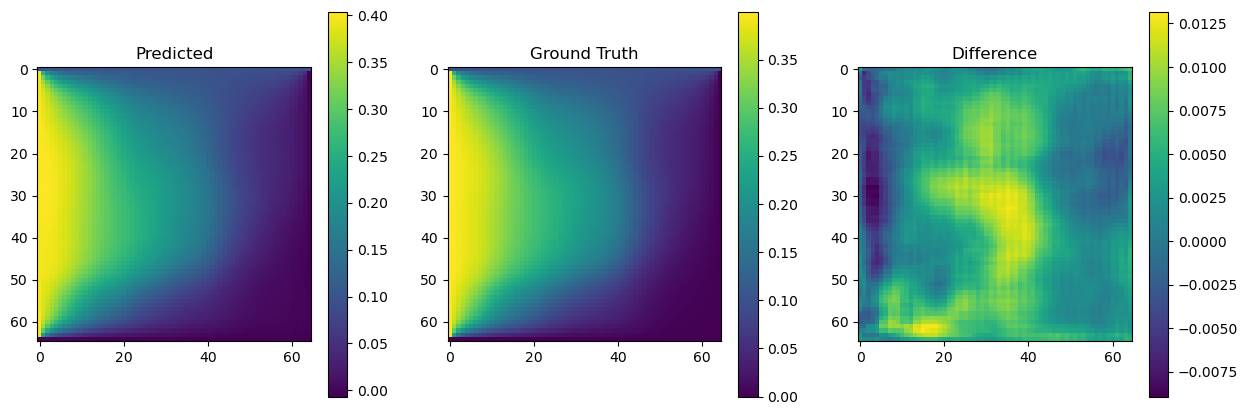

In [31]:
lfno.to('cpu')

i = np.random.randint(0, len(test_dataset))
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(denormalize(lfno(test_dataset[i][0][None]).detach().squeeze(), mean_sol, std_sol).numpy())
plt.colorbar()
plt.title('Predicted')

plt.subplot(1, 3, 2)
plt.imshow(denormalize(test_dataset[i][1].squeeze(), mean_sol, std_sol).numpy())
plt.colorbar()
plt.title('Ground Truth')

plt.subplot(1, 3, 3)
plt.imshow(denormalize(test_dataset[i][1].squeeze(), mean_sol, std_sol ).numpy() - denormalize(lfno(test_dataset[i][0][None]).detach().squeeze(), mean_sol, std_sol).numpy())
plt.colorbar()
plt.title('Difference')

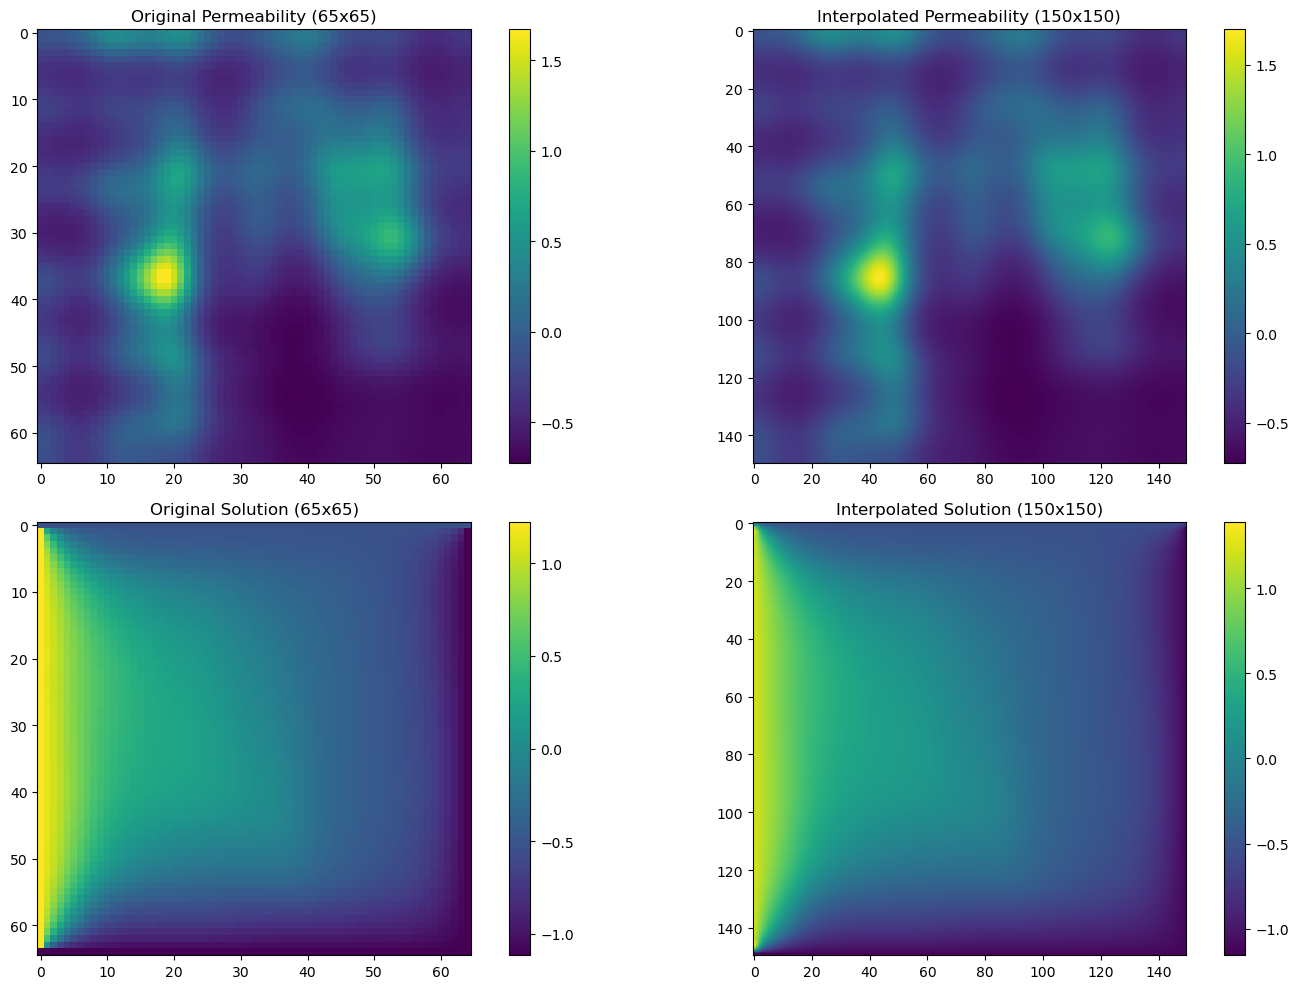

In [24]:
from scipy.interpolate import griddata
import numpy as np

# Get a test sample
i = np.random.randint(0, 100)  # Same index as used in the visualization cell
test_sample_perm = test_dataset[i][0].numpy().squeeze()
test_sample_sol = test_dataset[i][1].numpy().squeeze()

# Create original grid points
x_orig = np.linspace(0, 1, 65)
y_orig = np.linspace(0, 1, 65)
X_orig, Y_orig = np.meshgrid(x_orig, y_orig)

# Create new grid points with higher resolution
x_new = np.linspace(0, 1, 150)
y_new = np.linspace(0, 1, 150)
X_new, Y_new = np.meshgrid(x_new, y_new)

# Reshape the original points and values for interpolation
points = np.column_stack((X_orig.flatten(), Y_orig.flatten()))
values_perm = test_sample_perm.flatten()
values_sol = test_sample_sol.flatten()

# Interpolate
perm_highres = griddata(points, values_perm, (X_new, Y_new), method='cubic')
sol_highres = griddata(points, values_sol, (X_new, Y_new), method='cubic')

# Plot the results
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(test_sample_perm)
plt.colorbar()
plt.title('Original Permeability (65x65)')

plt.subplot(2, 2, 2)
plt.imshow(perm_highres)
plt.colorbar()
plt.title('Interpolated Permeability (150x150)')

plt.subplot(2, 2, 3)
plt.imshow(test_sample_sol)
plt.colorbar()
plt.title('Original Solution (65x65)')

plt.subplot(2, 2, 4)
plt.imshow(sol_highres)
plt.colorbar()
plt.title('Interpolated Solution (150x150)')

plt.tight_layout()

Text(0.5, 1.0, 'Difference')

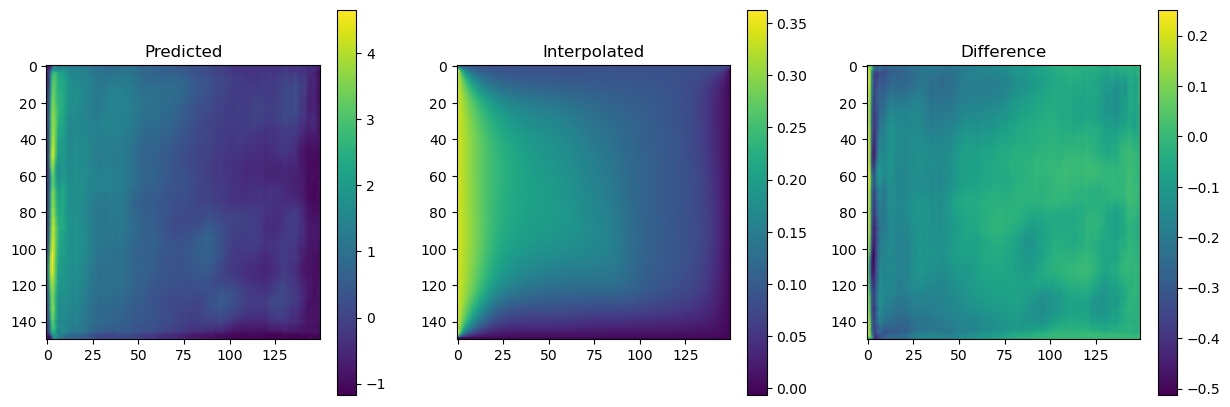

In [ ]:
from numpy import dtype


lfno.to('cpu')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lfno(th.tensor(perm_highres[None, None], dtype=th.float32)).detach().squeeze())
plt.colorbar()
plt.title('Predicted')

plt.subplot(1, 3, 2)
plt.imshow(denormalize(th.from_numpy(sol_highres), mean_sol, std_sol).numpy())
plt.colorbar()
plt.title('Interpolated')

plt.subplot(1, 3, 3)
plt.imshow(denormalize(th.from_numpy(sol_highres), mean_sol, std_sol).numpy() - denormalize(lfno(th.tensor(perm_highres[None, None], dtype=th.float32)).detach().squeeze(), mean_sol, std_sol).numpy())
plt.colorbar()
plt.title('Difference')